In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

df = pd.read_csv("D:\Projects and Hackathons\SmartSalary-Employee Salary Prediction\data\salary_data.csv")

In [6]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [7]:
df.shape

(250000, 10)

In [8]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [10]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [11]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
num_cols = df.select_dtypes(include=np.number).columns

In [15]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [16]:
cat_cols = df.select_dtypes(include='object').columns

In [17]:
df[cat_cols] = df[cat_cols].fillna("Unknown")

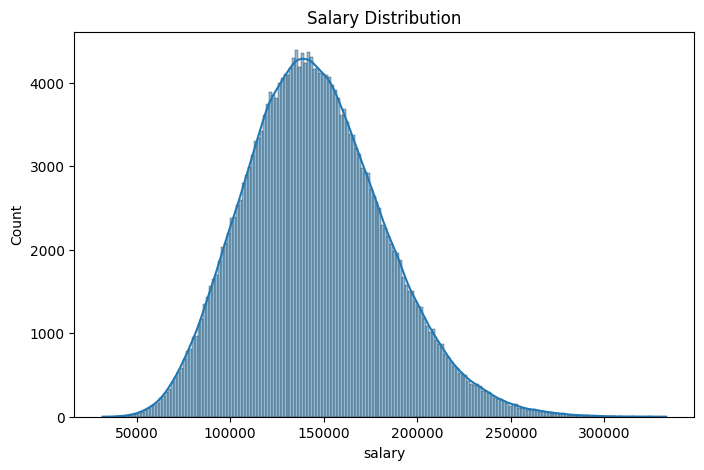

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

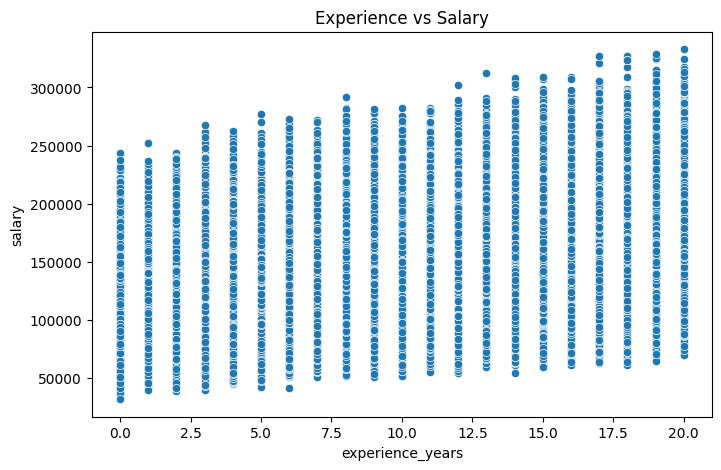

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="experience_years",
    y="salary",
    data=df
)
plt.title("Experience vs Salary")
plt.show()

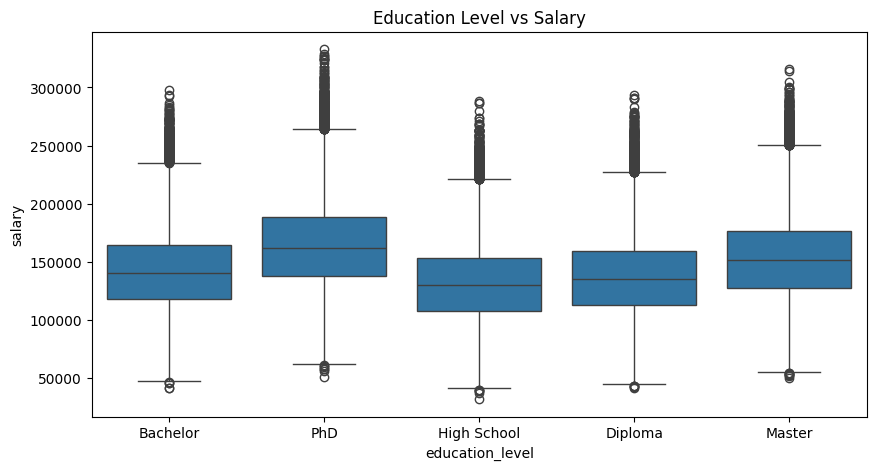

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="education_level",
    y="salary",
    data=df
)
plt.title("Education Level vs Salary")
plt.show()

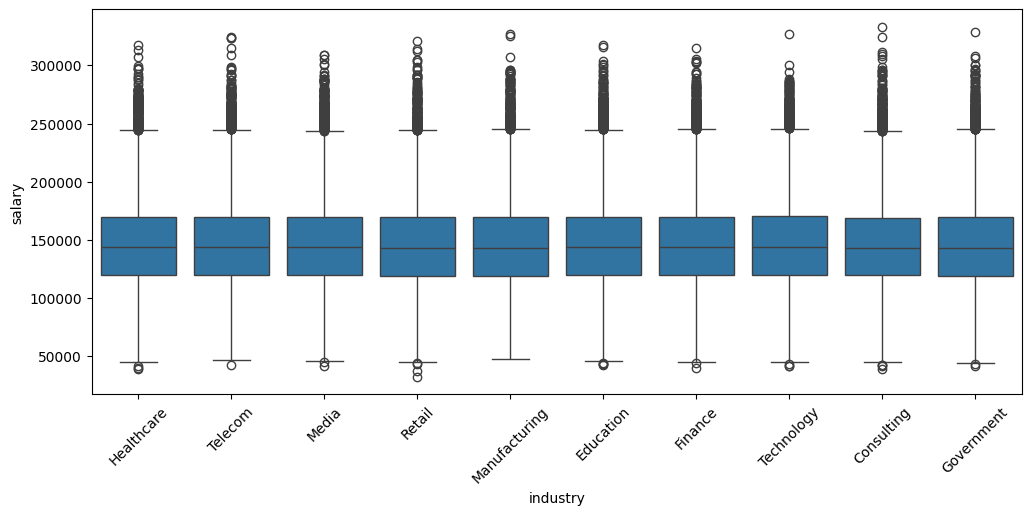

In [23]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x="industry",
    y="salary",
    data=df
)

plt.xticks(rotation=45)
plt.show()

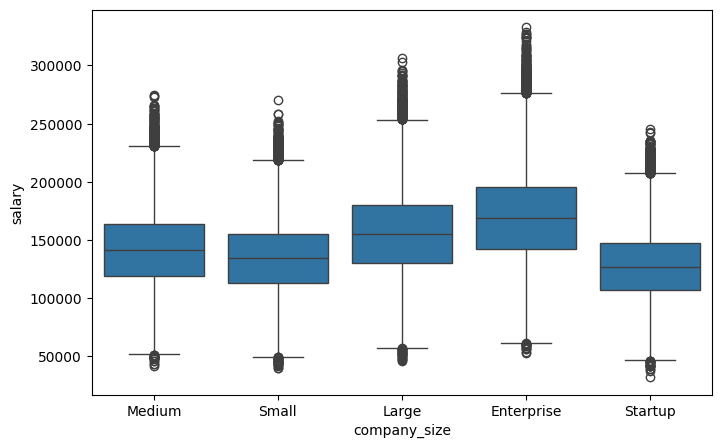

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="company_size",
    y="salary",
    data=df
)
plt.show()

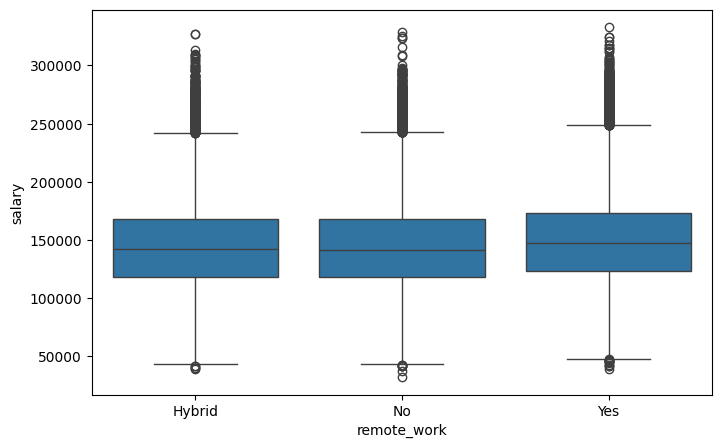

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="remote_work",
    y="salary",
    data=df
)
plt.show()

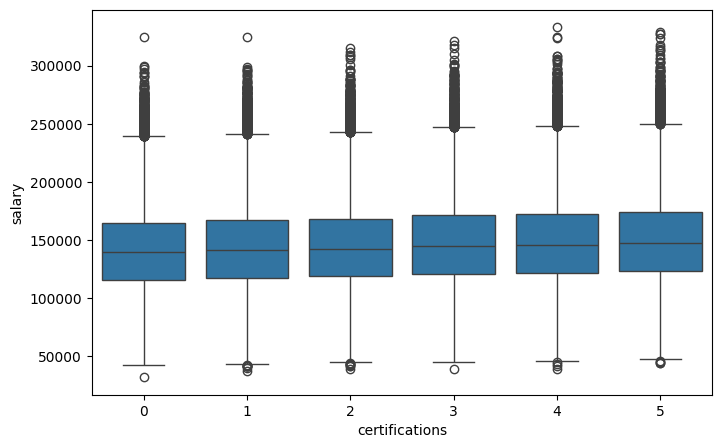

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="certifications",
    y="salary",
    data=df
)
plt.show()

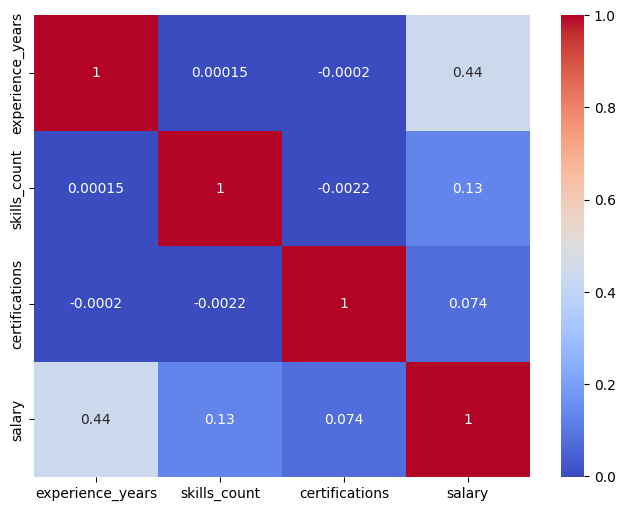

In [27]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [28]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [29]:
df_encoded.head()

,experience_years,skills_count,certifications,salary,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [31]:
X = df_encoded.drop(
    "salary",
    axis=1
)

y = df_encoded["salary"]

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [35]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

r2 = r2_score(
    y_test,
    lr_pred
)

print(rmse)
print(r2)

7125.5229041248895
0.9634690228446962


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 7375.756852502002
R² Score: 0.9608581821826041


In [38]:
comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': rf_pred
})

comparison.head(10)

,Actual Salary,Predicted Salary
38683,164009,158362.37
64939,79594,103929.23
3954,74090,70347.59
120374,177193,159340.51
172861,120012,114716.16
149303,163369,180167.09
111626,111889,111583.02
164553,75418,77047.22
55779,103067,96364.96
141990,190692,179688.25


In [39]:
print(rf)

RandomForestRegressor(random_state=42)


In [40]:
rf_pred[:10]

array([158362.37, 103929.23,  70347.59, 159340.51, 114716.16, 180167.09,
       111583.02,  77047.22,  96364.96, 179688.25])

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression RMSE: 7125.5229041248895
Linear Regression R²: 0.9634690228446962


In [43]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,experience_years,0.200342
33,location_India,0.181792
39,location_USA,0.075682
30,company_size_Startup,0.061108
17,education_level_PhD,0.060730
29,company_size_Small,0.050843
7,job_title_Data Analyst,0.044606
28,company_size_Medium,0.043669
4,job_title_Business Analyst,0.042465
31,location_Canada,0.034414


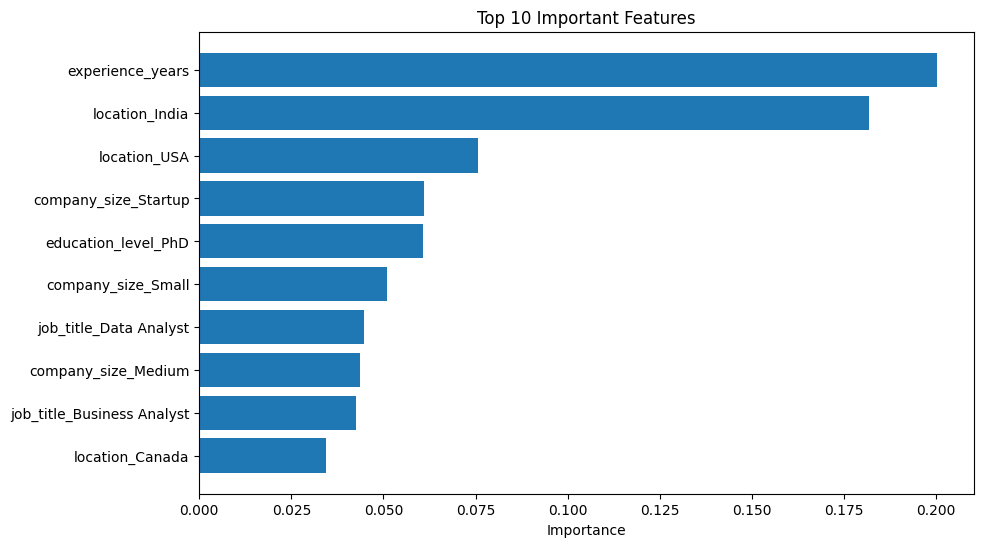

In [44]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

# Feature Importance Analysis

The Random Forest model identified the most influential factors affecting employee salary. Among all features, **experience_years** emerged as the strongest predictor, indicating that professional experience plays the most significant role in determining compensation.

Geographic location was also found to be highly influential. The features **location_India** and **location_USA** ranked among the top predictors, suggesting that salary structures vary considerably across different countries and labor markets.

Educational qualifications contributed substantially to salary prediction. In particular, holding a **PhD degree** was associated with higher compensation levels, highlighting the importance of advanced education in career growth and earning potential.

Company size also affected employee salaries. Features representing **startup**, **small**, and **medium-sized organizations** appeared among the most important variables, indicating that organizational scale influences compensation packages.

Job role played a meaningful role in salary variation. Positions such as **Data Analyst** and **Business Analyst** were identified as important predictors, demonstrating that different professional roles receive different compensation levels.

Overall, the analysis reveals that employee salary is primarily driven by a combination of **experience, location, education level, company size, and job role**. These findings align with real-world workforce trends and validate the effectiveness of the machine learning model in capturing salary patterns.


# Conclusion

This project developed a machine learning-based Employee Salary Prediction System using employee demographics, education, experience, job-related attributes, and organizational characteristics. The dataset was preprocessed through data cleaning, categorical encoding, and exploratory data analysis to uncover meaningful salary patterns.

Multiple machine learning techniques were evaluated, and the Random Forest Regressor achieved excellent predictive performance with an RMSE of approximately 7,376 and an R² score of 0.96. These results indicate that the model successfully explains over 96% of the variation in employee salaries.

Feature importance analysis showed that experience, geographic location, education level, company size, and job role are the most influential factors affecting compensation. The findings demonstrate how machine learning can be applied to workforce analytics to support salary estimation and compensation analysis.

Future improvements may include implementing advanced boosting algorithms such as XGBoost, deploying the model through a Streamlit web application, and incorporating additional employee attributes to further improve predictive performance.


In [45]:
import joblib

joblib.dump(
    rf,
    "../models/salary_model.pkl"
)

['../models/salary_model.pkl']

In [47]:
import os

os.listdir("../models")

['.gitkeep', 'salary_model.pkl']

In [48]:
loaded_model = joblib.load(
    "../models/salary_model.pkl"
)

print(loaded_model)

RandomForestRegressor(random_state=42)


In [49]:
loaded_model.predict(
    X_test.iloc[:5]
)

array([158362.37, 103929.23,  70347.59, 159340.51, 114716.16])